In [12]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent / 'src'))

In [13]:
import pandas as pd 
from utils import backtest_dca_pure,backtest_dca_plus_trading_WITH_SL,backtest_with_atr_SL,backtest_dca_plus_trading_NO_SL,backtest_dca_self_sufficient,evaluate_all_strategies

In [ ]:
df = pd.read_csv('../data/VOO_ind_signal.csv')     

In [15]:
#Parametros para los backtests 

estrategias_a_probar = [
    # Individuales
    'signal_ema_price',
    'signal_macd_buy',
    'signal_stochastic_buy',
    'signal_ichimoku_kijun_cross',
    'signal_bollinger_buy',
    
    # Combinadas
    'signal_macd_&_stochastic',
    'signal_ema_price_&_macd',
    'signal_ichimoku_kijun_cross_&_stochastic',
    'signal_ema_price_&_stochastic'    
]

params = {
    'monthly_invest': 250,
    'trade_amount': 150,
    'take_profit_pct': 0.125,
    'initial_trading_cash': 1000,
    'verbose': False 
}

params_atr = {
    'monthly_invest': 250,
    'trade_amount': 150,
    'atr_multiplier_tp': 10.0,   
    'atr_multiplier_sl': 3.0,  
    'initial_trading_cash': 1000,
    'verbose': False
}

### 1.Backtesting inicial antes del entrenamiento de modelos. 

#### 1.1 Backtesting estrategia Dollar Cost Average (DCA)

In [16]:
resultados_dca, df_dca = backtest_dca_pure(df, monthly_invest=250)

 Resultados para la estrategia: DCA Puro 
Valor Final del Portafolio: $113,480.61
Ganancia/Pérdida Absoluta: $71,480.61
Total Aportado: $42,000.00
Retorno Porcentual: 170.19%



#### 1.2 Backtesting con Stop Loss Fijos

In [17]:
print(" Iniciando Evaluación con Stops sin ATR")
df_resultados_finales = evaluate_all_strategies(df, estrategias_a_probar, backtest_dca_plus_trading_WITH_SL,params)

print("\n Tabla Comparativa de Estrategias")
display(df_resultados_finales)

 Iniciando Evaluación con Stops sin ATR
Evaluando: signal_ema_price...
Evaluando: signal_macd_buy...
Evaluando: signal_stochastic_buy...
Evaluando: signal_ichimoku_kijun_cross...
Evaluando: signal_bollinger_buy...
Evaluando: signal_macd_&_stochastic...
Evaluando: signal_ema_price_&_macd...
Evaluando: signal_ichimoku_kijun_cross_&_stochastic...
Evaluando: signal_ema_price_&_stochastic...

 Tabla Comparativa de Estrategias


,Strategy,Final Portfolio Value,Total Contributions,Absolute Return,Percentage Return,Trading PnL,Trading Capital Used,Open Trades at End,Value of Open Trades,Sharpe Ratio,Total DCA Shares
0,signal_ichimoku_kijun_cross (With SL),115382.177,43000,72382.177,168.331,883.613,20850,2,317.953,1.625,218.607
1,signal_macd_buy (With SL),114717.827,43000,71717.827,166.786,237.216,4500,0,0.000,1.627,218.607
2,signal_ema_price (With SL),114541.386,43000,71541.386,166.375,60.775,3750,0,0.000,1.624,218.607
3,signal_stochastic_buy (With SL),114526.703,43000,71526.703,166.341,46.093,3150,0,0.000,1.626,218.607
4,signal_ema_price_&_macd (With SL),114518.536,43000,71518.536,166.322,37.925,300,0,0.000,1.628,218.607
5,signal_ichimoku_kijun_cross_&_stochastic (With...,114511.544,43000,71511.544,166.306,30.933,1800,0,0.000,1.626,218.607
6,signal_bollinger_buy (With SL),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
7,signal_macd_&_stochastic (With SL),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
8,signal_ema_price_&_stochastic (With SL),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607


#### 1.3 Backtesting de incluyendo StopLoss dinamicos combinado con ATR 

In [18]:
print(" Iniciando Evaluación con Stops con ATR")

df_results_atr = evaluate_all_strategies(df, estrategias_a_probar,  backtest_with_atr_SL, params_atr)
print("\n Tabla Comparativa con Stops con ATR ")
display(df_results_atr)

 Iniciando Evaluación con Stops con ATR
Evaluando: signal_ema_price...
Evaluando: signal_macd_buy...
Evaluando: signal_stochastic_buy...
Evaluando: signal_ichimoku_kijun_cross...
Evaluando: signal_bollinger_buy...
Evaluando: signal_macd_&_stochastic...
Evaluando: signal_ema_price_&_macd...
Evaluando: signal_ichimoku_kijun_cross_&_stochastic...
Evaluando: signal_ema_price_&_stochastic...

 Tabla Comparativa con Stops con ATR 


,Strategy,Final Portfolio Value,Total Contributions,Absolute Return,Percentage Return,Trading PnL,Trading Capital Used,Open Trades at End,Value of Open Trades,Sharpe Ratio,Total DCA Shares
0,signal_ichimoku_kijun_cross (ATR Stops),115259.411,43000,72259.411,168.045,754.353,20700,3,474.447,1.621,218.607
1,signal_ema_price (ATR Stops),114740.613,43000,71740.613,166.839,260.002,3750,0,0.000,1.626,218.607
2,signal_macd_buy (ATR Stops),114662.037,43000,71662.037,166.656,181.427,4500,0,0.000,1.626,218.607
3,signal_ema_price_&_macd (ATR Stops),114514.515,43000,71514.515,166.313,33.905,300,0,0.000,1.628,218.607
4,signal_stochastic_buy (ATR Stops),114511.716,43000,71511.716,166.306,31.106,3150,0,0.000,1.625,218.607
5,signal_bollinger_buy (ATR Stops),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
6,signal_macd_&_stochastic (ATR Stops),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
7,signal_ema_price_&_stochastic (ATR Stops),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
8,signal_ichimoku_kijun_cross_&_stochastic (ATR ...,114439.630,43000,71439.630,166.139,-40.981,1800,0,0.000,1.625,218.607


#### 1.4 Backtesting sin Stop Loss ni ATR

In [19]:
print(" Iniciando Evaluación  sin Stops ni ATR")
df_resultados_finales = evaluate_all_strategies(df, estrategias_a_probar, backtest_dca_plus_trading_NO_SL,params)

print("\n Tabla Comparativa de Estrategias sin Stop ")
display(df_resultados_finales)

 Iniciando Evaluación  sin Stops ni ATR
Evaluando: signal_ema_price...
Evaluando: signal_macd_buy...
Evaluando: signal_stochastic_buy...
Evaluando: signal_ichimoku_kijun_cross...
Evaluando: signal_bollinger_buy...
Evaluando: signal_macd_&_stochastic...
Evaluando: signal_ema_price_&_macd...
Evaluando: signal_ichimoku_kijun_cross_&_stochastic...
Evaluando: signal_ema_price_&_stochastic...

 Tabla Comparativa de Estrategias sin Stop 


,Strategy,Final Portfolio Value,Total Contributions,Absolute Return,Percentage Return,Trading PnL,Trading Capital Used,Open Trades at End,Value of Open Trades,Sharpe Ratio,Total DCA Shares
0,signal_ichimoku_kijun_cross (No SL),116532.304,43000,73532.304,171.005,2044.032,17100,8,1207.662,1.621,218.607
1,signal_macd_buy (No SL),114972.517,43000,71972.517,167.378,499.262,4050,1,142.644,1.627,218.607
2,signal_ema_price (No SL),114936.406,43000,71936.406,167.294,457.743,3750,1,148.052,1.628,218.607
3,signal_stochastic_buy (No SL),114883.412,43000,71883.412,167.171,402.801,3150,0,0.000,1.627,218.607
4,signal_ichimoku_kijun_cross_&_stochastic (No SL),114713.229,43000,71713.229,166.775,232.618,1800,0,0.000,1.627,218.607
5,signal_ema_price_&_macd (No SL),114518.536,43000,71518.536,166.322,37.925,300,0,0.000,1.628,218.607
6,signal_bollinger_buy (No SL),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
7,signal_macd_&_stochastic (No SL),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607
8,signal_ema_price_&_stochastic (No SL),114480.611,43000,71480.611,166.234,0.000,0,0,0.000,1.627,218.607


#### ESTRATEGIA SELF SUFFICIENT (NO DEFINITIVA)

Evaluando: signal_ema_price...


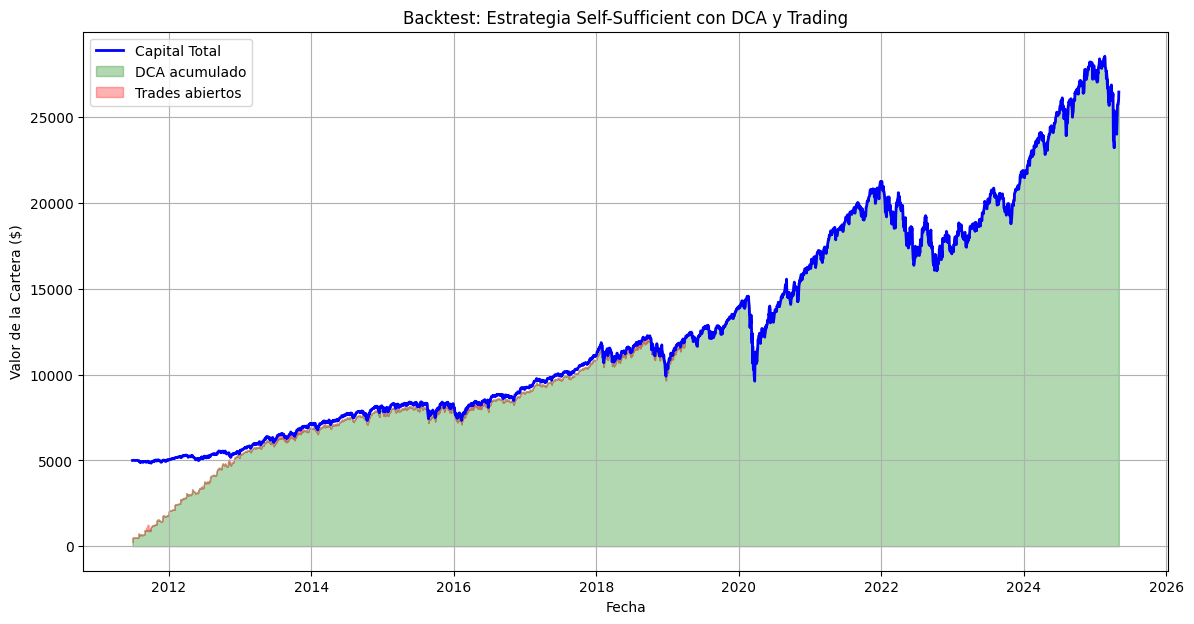

Evaluando: signal_macd_buy...


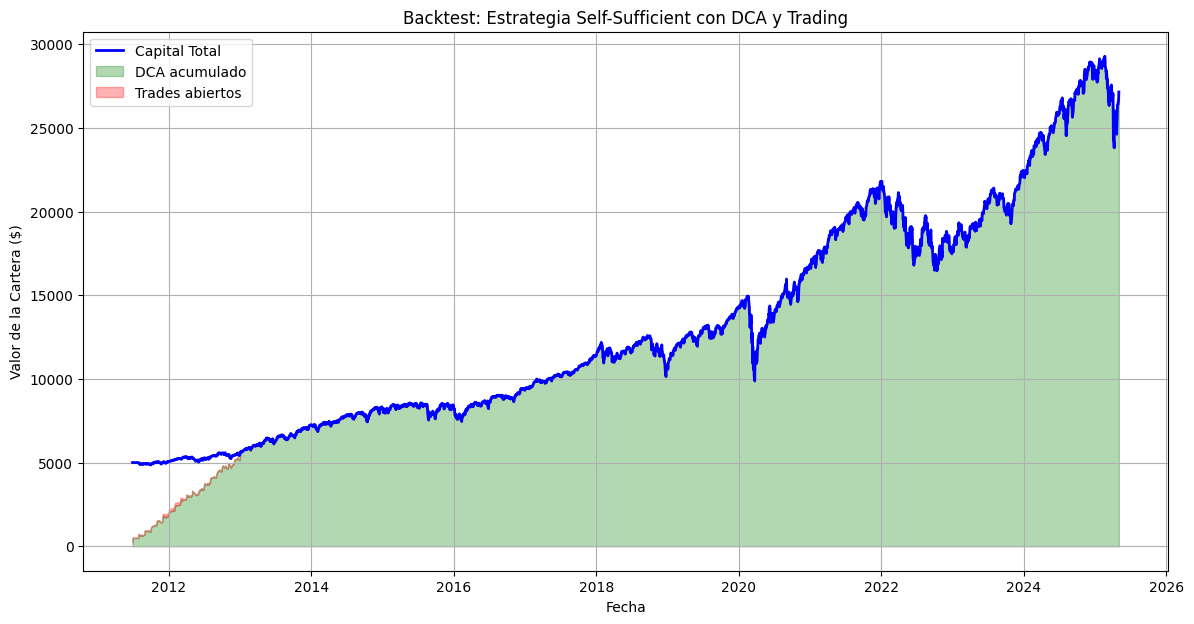

Evaluando: signal_stochastic_buy...


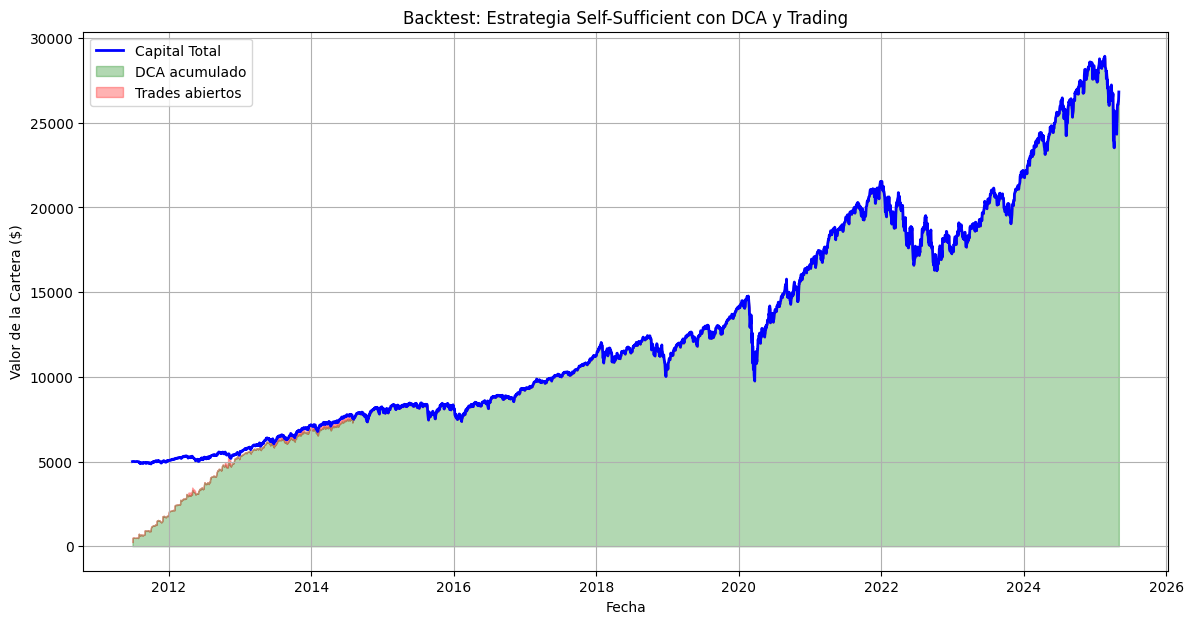

Evaluando: signal_ichimoku_kijun_cross...


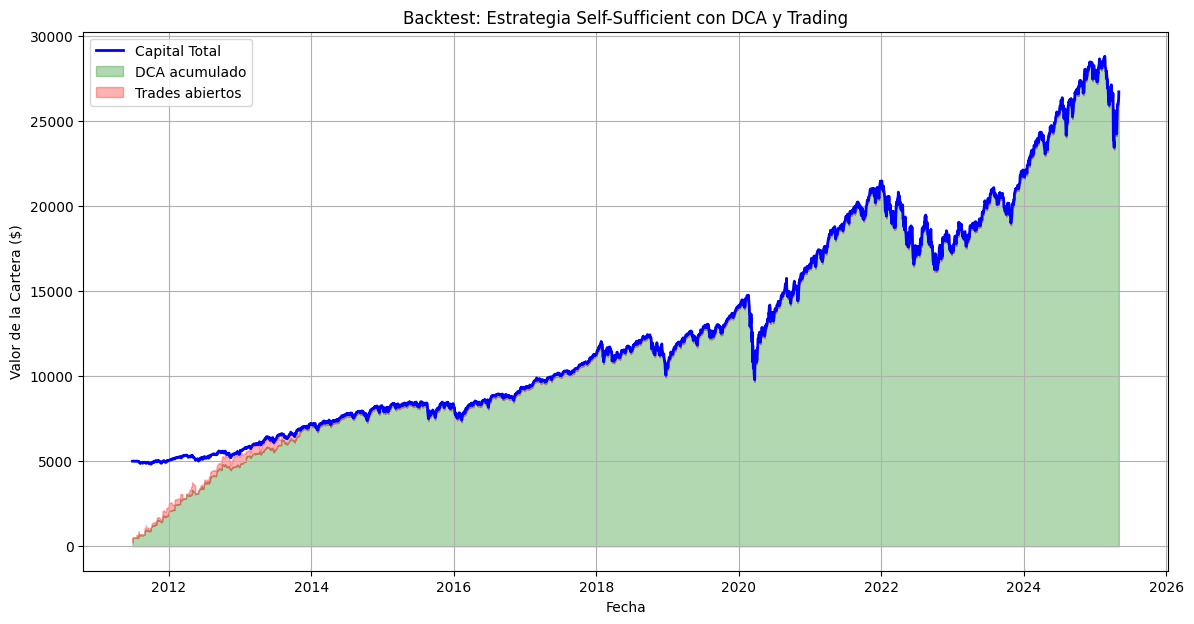

Evaluando: signal_bollinger_buy...


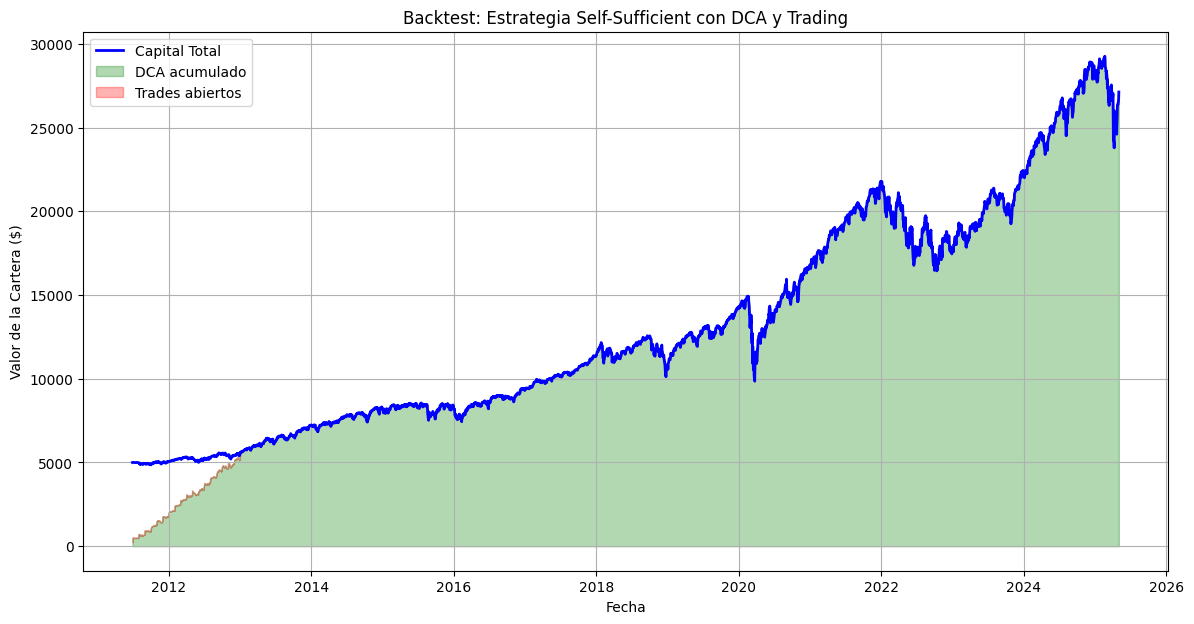

Evaluando: signal_macd_&_stochastic...


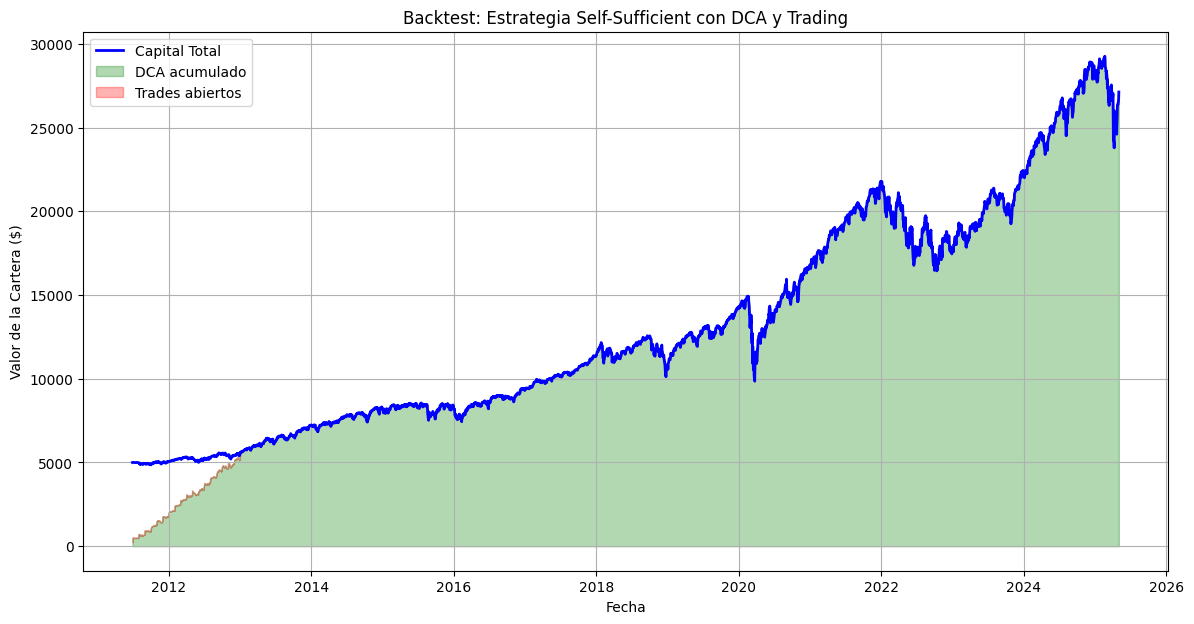

Evaluando: signal_ema_price_&_macd...


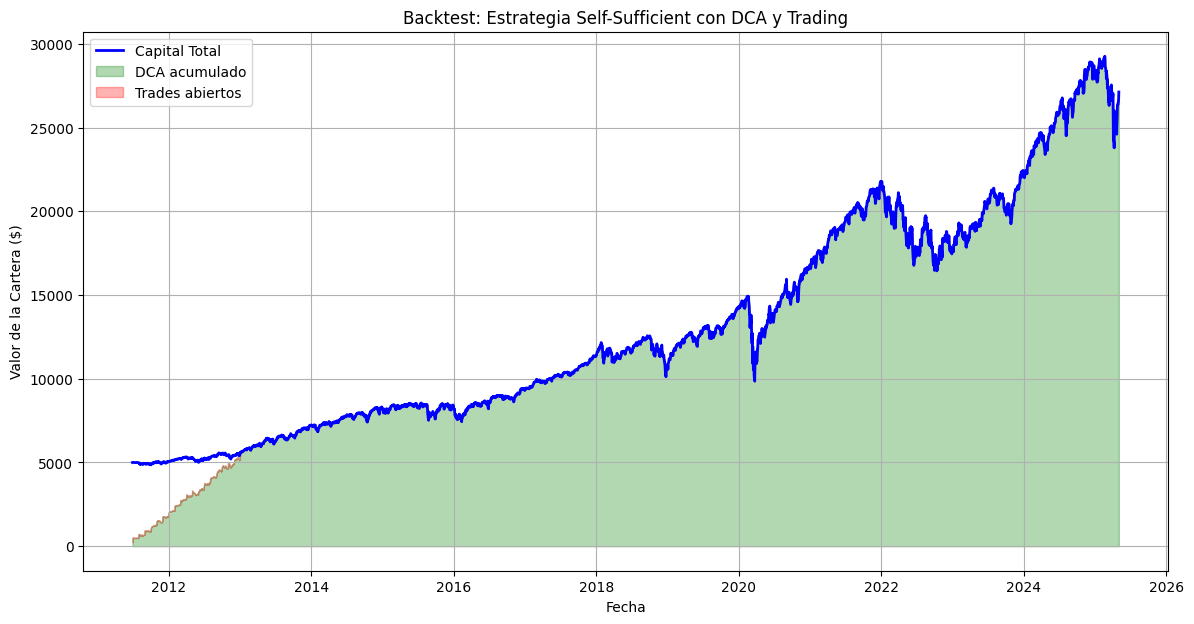

Evaluando: signal_ichimoku_kijun_cross_&_stochastic...


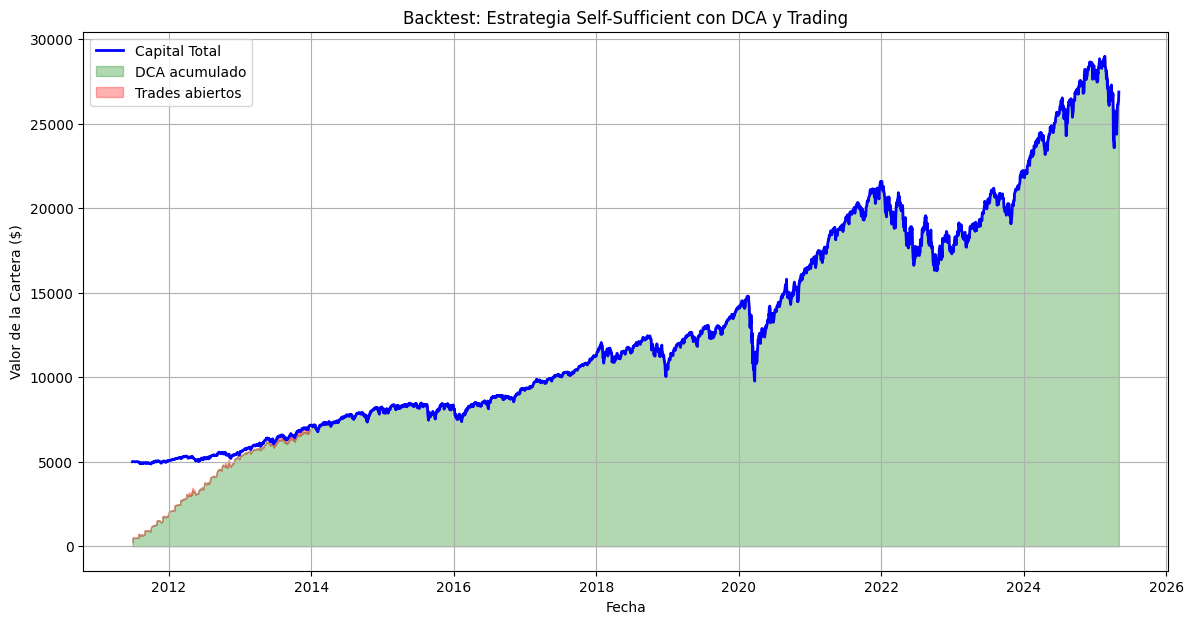

Evaluando: signal_ema_price_&_stochastic...


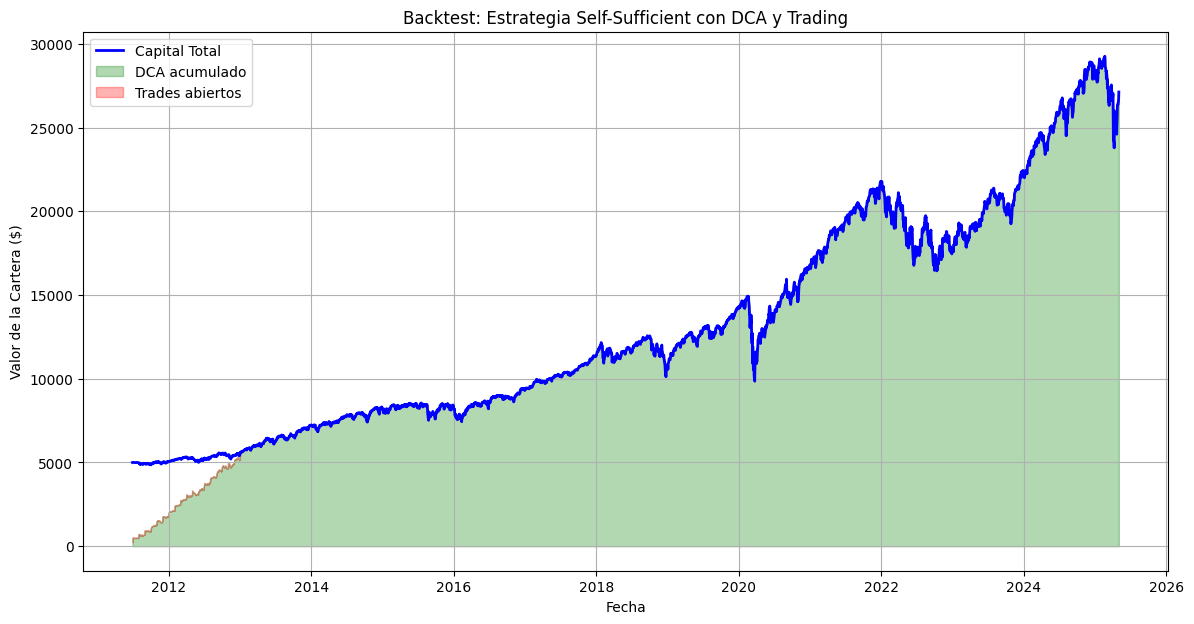


 Tabla Comparativa de Estrategia selfsufficient 


,Strategy,Final Portfolio Value,Total Contributions,Absolute Return,Percentage Return,Trading PnL,Trading Capital Used,Open Trades at End,Value of Open Trades,Sharpe Ratio,DCA Total Shares,DCA Shares Value
0,signal_macd_buy (Self-Sufficient),27144.625,10000,17144.625,171.446,19.288,150,0,0,0.706,52.254,27125.337
1,signal_bollinger_buy (Self-Sufficient),27125.337,10000,17125.337,171.253,0.000,0,0,0,0.705,52.254,27125.337
2,signal_macd_&_stochastic (Self-Sufficient),27125.337,10000,17125.337,171.253,0.000,0,0,0,0.705,52.254,27125.337
3,signal_ema_price_&_macd (Self-Sufficient),27125.337,10000,17125.337,171.253,0.000,0,0,0,0.705,52.254,27125.337
4,signal_ema_price_&_stochastic (Self-Sufficient),27125.337,10000,17125.337,171.253,0.000,0,0,0,0.705,52.254,27125.337
5,signal_ichimoku_kijun_cross_&_stochastic (Self...,26863.708,10000,16863.708,168.637,3.114,450,0,0,0.701,51.744,26860.595
6,signal_stochastic_buy (Self-Sufficient),26818.865,10000,16818.865,168.189,13.955,750,0,0,0.701,51.637,26804.910
7,signal_ichimoku_kijun_cross (Self-Sufficient),26708.742,10000,16708.742,167.087,115.975,2850,0,0,0.702,51.228,26592.767
8,signal_ema_price (Self-Sufficient),26465.664,10000,16465.664,164.657,3.603,1350,0,0,0.697,50.976,26462.061


In [21]:
# Deshabilitar gráficos
params['plot'] = True
params['initial_trading_cash']=5000

df_resultados_finales = evaluate_all_strategies(df, estrategias_a_probar, backtest_dca_self_sufficient, params)

print("\n Tabla Comparativa de Estrategia selfsufficient ")
display(df_resultados_finales)